In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../')) 

import pandas as pd
from src.simulation import FastFoodChain_scenario3

In [ ]:
df_util_scenario_1 = pd.DataFrame(obj3.util_log)
df_util_scenario_1["Hour"] = (df_util_scenario_1['Time'] / 60).astype(int)
hourly_stats_scenario_1 = df_util_scenario_1.groupby("Hour").mean().reset_index()
hourly_stats_scenario_1["Front_counter_Associate"] = (hourly_stats_scenario_1['Front_counter_Associate'] / obj3.associate.capacity) * 100
hourly_stats_scenario_1["Cook"] = (hourly_stats_scenario_1["Cook"]/obj3.cook.capacity)*100
hourly_stats_scenario_1["Order_fullfillment_Associate"] = (hourly_stats_scenario_1["Order_fullfillment_Associate"]/obj3.order_fullfillment.capacity)*100


time_labels = {
    0: "06:00 - 07:00", 1: "07:00 - 08:00", 2: "08:00 - 09:00",
    3: "09:00 - 10:00", 4: "10:00 - 11:00", 5: "11:00 - 12:00",
    6: "12:00 - 13:00", 7: "13:00 - 14:00", 8: "14:00 - 15:00",
    9: "15:00 - 16:00", 10: "16:00 - 17:00", 11: "17:00 - 18:00",
    12: "18:00 - 19:00", 13: "19:00 - 20:00", 14: "20:00 - 21:00",
    15: "21:00 - 22:00", 16: "22:00 - 23:00", 17: "23:00 - 00:00",
    18: "00:00 - 01:00", 19: "01:00 - 02:00"
}
hourly_stats_scenario_1["Hour"] = hourly_stats_scenario_1["Hour"].replace(time_labels)
hourly_stats_scenario_1

,Hour,Time,Front_counter_Associate,Cook,Order_fullfillment_Associate,Production_Wait_Queue,Order_Fullfillment_Associate_queue,Front_Counter_Associate_queue
0,06:00 - 07:00,30.000,24.396336,28.948099,26.810991,0.100749,0.061615,0.119067
1,07:00 - 08:00,90.025,8.833333,20.638889,18.916667,0.000000,0.000000,0.000000
2,08:00 - 09:00,150.000,55.379483,52.126772,52.376981,0.041701,0.139283,0.260217
3,09:00 - 10:00,209.975,42.500000,40.555556,42.416667,0.037500,0.056667,0.130000
4,10:00 - 11:00,269.975,16.333333,27.888889,26.916667,0.000000,0.023333,0.000000
5,11:00 - 12:00,329.975,54.250000,54.166667,55.875000,0.214167,0.221667,0.330000
6,12:00 - 13:00,389.975,77.333333,73.361111,78.958333,0.349167,0.940833,0.566667
7,13:00 - 14:00,449.975,71.833333,74.861111,80.458333,0.964167,0.962500,1.560000
8,14:00 - 15:00,509.975,31.166667,35.583333,37.375000,0.000000,0.034167,0.073333
9,15:00 - 16:00,569.975,30.750000,30.055556,30.750000,0.008333,0.064167,0.033333


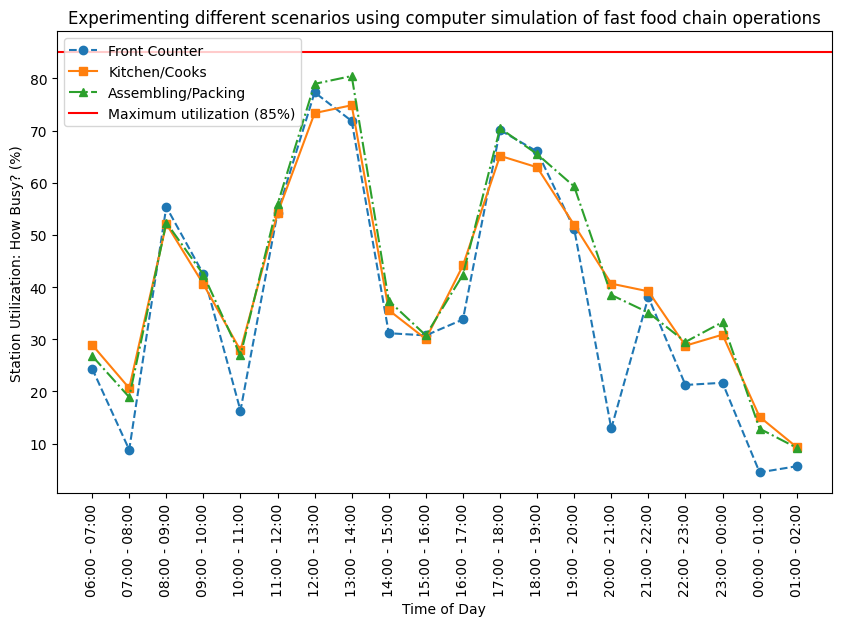

In [89]:
plt.figure(figsize=(10,6))
plt.plot(  hourly_stats_scenario_1["Hour"],  hourly_stats_scenario_1["Front_counter_Associate"], label = "Front Counter", ls = "--" , marker = "o")
plt.plot( hourly_stats_scenario_1["Hour"],  hourly_stats_scenario_1["Cook"], label= "Kitchen/Cooks" , ls = "-", marker = "s")
plt.plot( hourly_stats_scenario_1["Hour"],  hourly_stats_scenario_1["Order_fullfillment_Associate"], label= "Assembling/Packing", ls = "-.", marker = "^" )
plt.axhline( y = 85, color = "r", linestyle = "-", label="Maximum utilization (85%)")
plt.xticks(rotation = 90)
plt.xlabel("Time of Day")
plt.ylabel("Station Utilization: How Busy? (%)")
plt.title("Experimenting different scenarios using computer simulation of fast food chain operations")
plt.legend(loc = "upper left")
plt.show()